# Limpieza y Analisis a detalle de la base de datos


In [1]:
import sys
sys.path.append("..")  # subir un nivel

from scripts import bases, init_notebook
ctx = init_notebook()

df_pacientes = ctx["df_pacientes"]
traslados = ctx["traslados"]
hosp_coords = ctx["hosp_coords"]
municipios = ctx["municipios"]
municipios_amba = ctx["municipios_amba"]

TypeError: 'module' object is not callable

In [37]:
(len(traslados)/len(df_pacientes))*100

5.9368265086206895

In [38]:
df_pacientes["Nombre Hospital"].unique()

<StringArray>
[                 'EL CRUCE',                 'MI PUEBLO',
 'MODULO HOSPITALARIO 11 FV',                     'OLLER',
                   'IRIARTE', 'MODULO HOSPITALARIO 10 QU',
            'LUCIO MELENDEZ',                  'ONATIVIA',
  'MODULO HOSPITALARIO 9 AB',              'EVITA PUEBLO',
                  'UPA 5 AB',                 'UPA 11 FV',
                 'UPA 17 QU',                 'UPA 10 BE',
  'MODULO HOSPITALARIO 8 LZ']
Length: 15, dtype: str

## 1. Funcionamiento de la Red General (AMBA)

### 1.1 Mapa con los hospitales y sus municipios alrededor

Registros luego de filtros: 1763
Hospitales origen únicos: 13
Hospitales destino únicos: 13
Nodos en red: 14
Aristas en red: 51


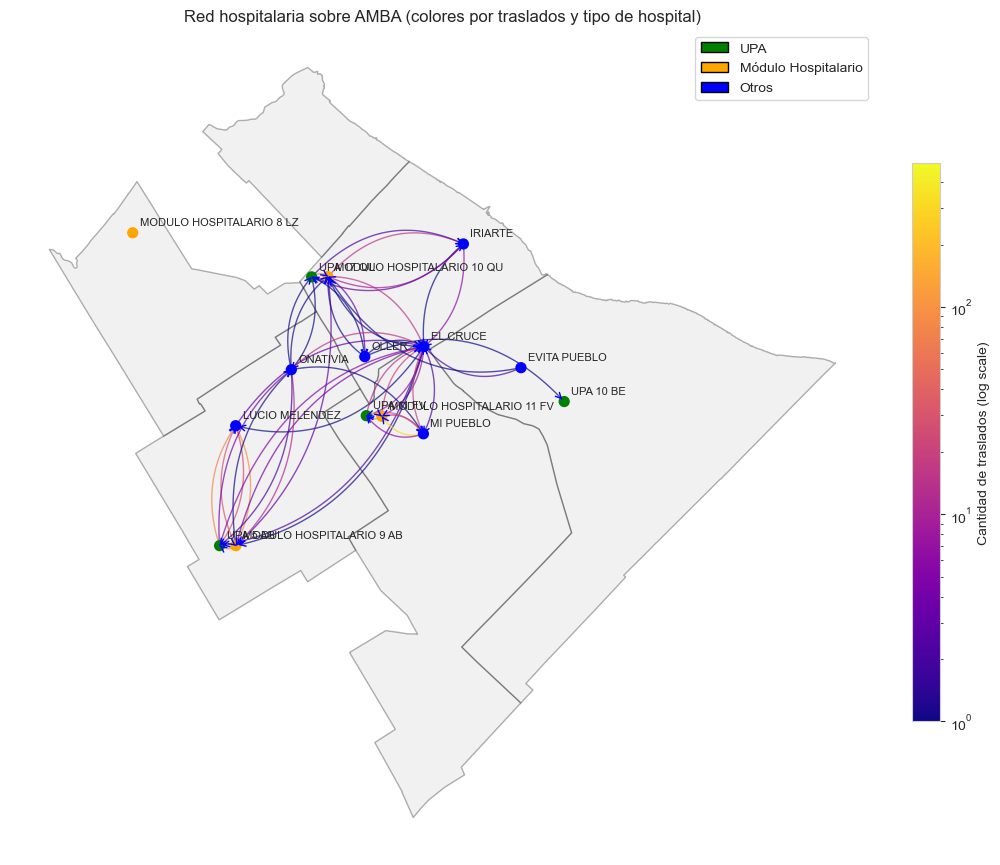

In [39]:
# Generar red
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=1, 
    modo="estatico", 
    mostrar_resumen=True, 
    graficar=False
)

# Convertir red y nodos a GeoDataFrames con curvas
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria_curva(G, hosp_coords, curva_base=0.3)

# Graficar sobre AMBA
bases.plot_red_sobre_amba(gdf_edges, gdf_nodes, municipios_amba, mostrar_nombres=True, mostrar_peso=False)

In [40]:
#### direccionar
#### cuurvadas
#### elegir sistema para los upas

### 1.2 Total de traslados

In [41]:
# Resumen de traslados
res_tras = bases.resumen_traslados(traslados, imprimir=True)

Total de traslados: 1763
Cantidad de hospitales únicos: 13


In [42]:
traslados

,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,...,Pasó por Generales,Duracion días,murio,Hospital siguiente,Fecha ingreso siguiente,dias_entre_hospitales,es_traslado,error_fecha,posible_interno,gravedad_error
26566,147,UPA 17 QU,1,2020-05-01 12:11:27,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,36,...,no,94.0,False,ONATIVIA,2020-05-19 12:11:20,-77.0,True,True,False,2
14986,8,ONATIVIA,4,2020-05-31 12:11:19,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,17,...,no,11.0,False,UPA 17 QU,2020-06-08 12:11:27,-3.0,True,True,False,2
24049,145,UPA 5 AB,AA31,2022-04-22 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,56,...,no,1.0,False,MODULO HOSPITALARIO 9 AB,2022-04-23 12:11:21,-1.0,True,True,True,1
24252,145,UPA 5 AB,AA47,2022-06-05 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,femenino,47,...,no,3.0,False,MODULO HOSPITALARIO 9 AB,2022-06-08 12:11:21,-1.0,True,True,True,1
25122,146,UPA 11 FV,AB13,2020-08-07 12:11:26,sospechosos,intermedias,sospechosos,intermedias,masculino,56,...,no,3.0,False,MODULO HOSPITALARIO 11 FV,2020-08-10 12:11:10,-1.0,True,True,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19894,9,MODULO HOSPITALARIO 9 AB,ZY87,2022-02-18 12:11:21,ocupadas_otros,criticas,ocupadas_otros,criticas,masculino,66,...,no,3.0,False,UPA 5 AB,2022-02-18 12:11:25,-3.0,True,True,False,2
25614,146,UPA 11 FV,ZZ37,2021-04-15 12:11:26,ocupadas_covid,intermedias,ocupadas_covid,intermedias,masculino,62,...,no,2.0,False,MODULO HOSPITALARIO 11 FV,2021-04-17 12:11:10,-1.0,True,True,True,1
25659,146,UPA 11 FV,ZZ63,2021-04-24 12:11:26,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,54,...,no,1.0,False,MODULO HOSPITALARIO 11 FV,2021-04-25 12:11:10,-1.0,True,True,True,1
25855,146,UPA 11 FV,ZZ79,2021-06-10 12:11:26,sospechosos,intermedias,ocupadas_covid,intermedias,femenino,59,...,no,2.0,False,MODULO HOSPITALARIO 11 FV,2021-06-12 12:11:10,-1.0,True,True,True,1


### 1.3 Cantidad de traslados en función del tiempo

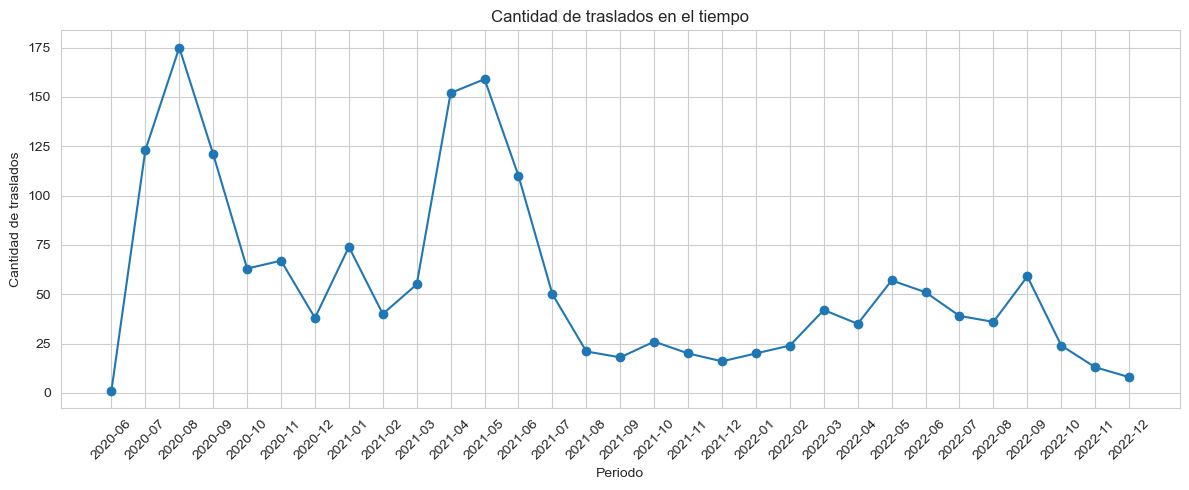

Fecha egreso
2020-06      1
2020-07    123
2020-08    175
2020-09    121
2020-10     63
2020-11     67
2020-12     38
2021-01     74
2021-02     40
2021-03     55
2021-04    152
2021-05    159
2021-06    110
2021-07     50
2021-08     21
2021-09     18
2021-10     26
2021-11     20
2021-12     16
2022-01     20
2022-02     24
2022-03     42
2022-04     35
2022-05     57
2022-06     51
2022-07     39
2022-08     36
2022-09     59
2022-10     24
2022-11     13
2022-12      8
dtype: int64

In [43]:
bases.traslados_en_el_tiempo(traslados, freq="M")

### 1.4 Top de flujos entre hospitales (Caminos más frecuentes)

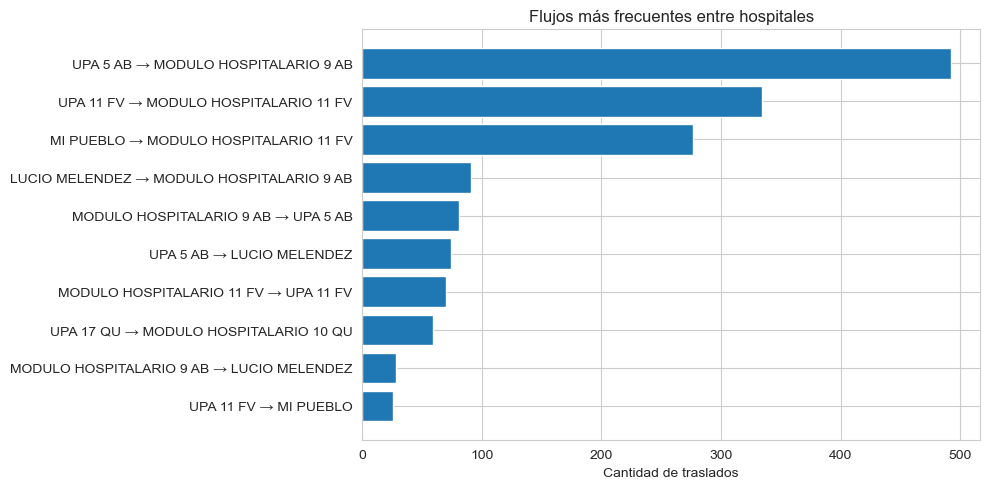

,Nombre Hospital,Hospital siguiente,cantidad
49,UPA 5 AB,MODULO HOSPITALARIO 9 AB,492
42,UPA 11 FV,MODULO HOSPITALARIO 11 FV,334
17,MI PUEBLO,MODULO HOSPITALARIO 11 FV,277
14,LUCIO MELENDEZ,MODULO HOSPITALARIO 9 AB,91
30,MODULO HOSPITALARIO 9 AB,UPA 5 AB,81
48,UPA 5 AB,LUCIO MELENDEZ,74
26,MODULO HOSPITALARIO 11 FV,UPA 11 FV,70
44,UPA 17 QU,MODULO HOSPITALARIO 10 QU,59
28,MODULO HOSPITALARIO 9 AB,LUCIO MELENDEZ,28
41,UPA 11 FV,MI PUEBLO,26


In [44]:
bases.top_flujos_hospitales(traslados, top_n=10)

### 1.5 Métricas de la red (Grafos)

In [45]:
bases.metricas_red(G, top_n=10)

Top hospitales por betweenness:
                     hospital  degree_centrality  betweenness  in_degree  \
0                    EL CRUCE           1.461538     0.481838        104   
12                   ONATIVIA           0.692308     0.226496          6   
10                  UPA 17 QU           0.538462     0.199786          7   
11                      OLLER           0.384615     0.193376          4   
6    MODULO HOSPITALARIO 9 AB           0.692308     0.122863        598   
4   MODULO HOSPITALARIO 10 QU           0.846154     0.057692         72   
3                   MI PUEBLO           0.538462     0.042735         40   
5   MODULO HOSPITALARIO 11 FV           0.461538     0.000000        618   
1                     IRIARTE           0.461538     0.000000         18   
2              LUCIO MELENDEZ           0.461538     0.000000        103   

    out_degree  
0           22  
12          31  
10          63  
11           3  
6          114  
4           39  
3          3

,hospital,degree_centrality,betweenness,in_degree,out_degree
0,EL CRUCE,1.461538,0.481838,104,22
12,ONATIVIA,0.692308,0.226496,6,31
10,UPA 17 QU,0.538462,0.199786,7,63
11,OLLER,0.384615,0.193376,4,3
6,MODULO HOSPITALARIO 9 AB,0.692308,0.122863,598,114
4,MODULO HOSPITALARIO 10 QU,0.846154,0.057692,72,39
3,MI PUEBLO,0.538462,0.042735,40,302
5,MODULO HOSPITALARIO 11 FV,0.461538,0.000000,618,101
1,IRIARTE,0.461538,0.000000,18,18
2,LUCIO MELENDEZ,0.461538,0.000000,103,118


In [46]:
### Quizas poner par a par
# pagerank

## 2. Trayectorias de Paciente

### 2.1 Cantidad de traslados para cada persona (promedio y desvío, junto a distribución)

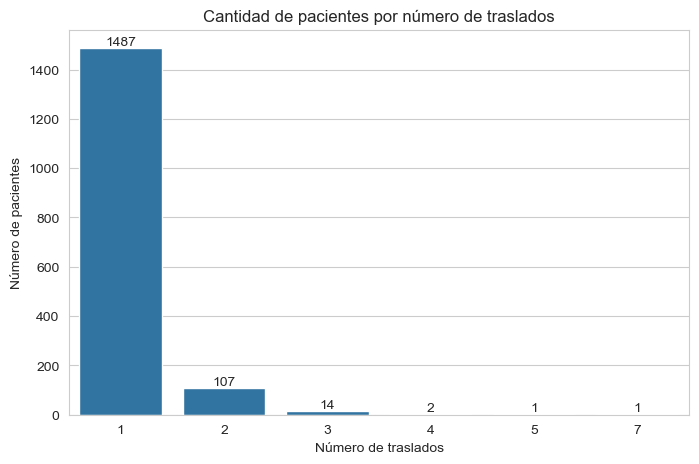

Promedio de traslados por paciente: 1.0936724565756824
Desvío estándar: 0.36857928377450805


In [47]:
# Distribución de traslados por paciente
conteo_tras_paciente, stats_tras_paciente = bases.distribucion_traslados_paciente(traslados, col_id="Id", valores=[1, 2, 3, 4, 5, 6, 7], graficar=True)

In [48]:
## que paso con estos 3?
## reconstruir estos 3

# incluir los ingresos como porcentaje. escala logaritmica

# PROBABILIDAD DE TENER UN TRASLADO MAS DADO LA CANTIDAD DE TRASLADOS QUE TUVISTE

# Cuantos de esos tambien tienen como lo que tuviste

In [49]:
#bases.revisar_dias_negativos(traslados, max_pacientes=10)

In [50]:
# pacientes con error
errores = traslados[traslados["error_fecha"]]
print("Pacientes con errores de fechas:", errores["Id"].unique())

# historial completo de un paciente con error
# usar el DataFrame de traslados que tiene las columnas calculadas
pid = errores["Id"].iloc[1]

historial = traslados[traslados["Id"] == pid].sort_values("Fecha inicio")

display(historial[[
    "Nombre Hospital",
    "Fecha inicio",
    "Fecha egreso",
    "Hospital siguiente",
    "Fecha ingreso siguiente",
    "dias_entre_hospitales",
    "error_fecha",
    "gravedad_error"
]])

Pacientes con errores de fechas: [1 4 'AA31' ... 'ZZ63' 'ZZ79' 'ZZ99']


,Nombre Hospital,Fecha inicio,Fecha egreso,Hospital siguiente,Fecha ingreso siguiente,dias_entre_hospitales,error_fecha,gravedad_error
14986,ONATIVIA,2020-05-31 12:11:19,2020-06-11 12:11:19,UPA 17 QU,2020-06-08 12:11:27,-3.0,True,2


In [68]:
# pacientes con >=3 traslados
traslados_muchos = bases.pacientes_con_muchos_traslados(traslados, minimo=3)

# imprimir recorridos
# bases.imprimir_recorridos_pacientes(
#     traslados_muchos,
#     col_id="Id",
#     col_origen="Nombre Hospital",
#     col_destino="Hospital siguiente"
# )

In [78]:
def detectar_rebotes(df, umbral_dias=1):
    
    rebotes = df[
        (df["dias_entre_hospitales"] >= 0) &
        (df["dias_entre_hospitales"] <= umbral_dias)
    ]
    
    print("Cantidad de rebotes:", len(rebotes))
    
    display(
        rebotes[[
            "Id",
            "Nombre Hospital",
            "Hospital siguiente",
            "dias_entre_hospitales"
        ]].head(10)
    )
    
    return rebotes

rebotes=detectar_rebotes(traslados)
df_pacientes.head(5)

Cantidad de rebotes: 502


,Id,Nombre Hospital,Hospital siguiente,dias_entre_hospitales
12188,AE01,LUCIO MELENDEZ,MODULO HOSPITALARIO 9 AB,0.0
13810,AG37,LUCIO MELENDEZ,MODULO HOSPITALARIO 9 AB,0.0
12281,AG38,LUCIO MELENDEZ,UPA 5 AB,0.0
3266,AG82,MI PUEBLO,MODULO HOSPITALARIO 11 FV,0.0
19893,AG92,MODULO HOSPITALARIO 9 AB,UPA 5 AB,0.0
12813,AI34,LUCIO MELENDEZ,MODULO HOSPITALARIO 9 AB,0.0
13059,AJ43,LUCIO MELENDEZ,MODULO HOSPITALARIO 9 AB,0.0
13117,AJ79,LUCIO MELENDEZ,MODULO HOSPITALARIO 9 AB,0.0
5152,AL12,MI PUEBLO,MODULO HOSPITALARIO 11 FV,0.0
3357,AL97,MI PUEBLO,MODULO HOSPITALARIO 11 FV,0.0


,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,...,Asistencia Respiratoria Mecánica,Motivo,Operación,Fecha egreso,Última actualización,Pasó por Críticas,Pasó por Intermedias,Pasó por Generales,Duracion días,murio
0,1,EL CRUCE,Mariano,NaT,sospechosos,criticas,sospechosos,criticas,NaN,NaN,...,NaN,NaN,NaN,NaT,2020-07-21 14:34:40,si,no,no,NaN,False
1,1,EL CRUCE,12345,NaT,sospechosos,intermedias,sospechosos,criticas,NaN,40,...,NaN,NaN,NaN,NaT,2020-07-21 14:34:40,si,si,no,NaN,False
2,1,EL CRUCE,24698750,2020-05-10 12:11:05,sospechosos,criticas,sospechosos,criticas,femenino,44,...,NaN,NaN,NaN,NaT,2020-07-21 14:34:40,si,no,no,NaN,False
3,1,EL CRUCE,1001,2020-05-28 12:11:05,ocupadas_covid,intermedias,ocupadas_covid,intermedias,masculino,49,...,NaN,alta-domiciliaria,egreso,2020-06-09 12:11:05,2020-07-21 14:34:40,no,si,no,12.0,False
4,1,EL CRUCE,1002,2020-05-15 12:11:05,ocupadas_covid,criticas,ocupadas_covid,intermedias,femenino,NaN,...,NaN,NaN,NaN,NaT,2020-07-21 14:34:40,si,si,no,NaN,False


In [67]:
#bases.graficar_estado_paciente_debug(traslados_muchos.head(5))

In [54]:
# ------------------------------
# EJECUCIÓN EN EL NOTEBOOK
# ------------------------------
# Mostrar tablas por paciente
bases.mostrar_recorridos_estado(traslados_muchos.head(9))

# Sankey de flujo
bases.sankey_pacientes(traslados_muchos)


Paciente AB52 - 3 traslados


,Nombre Hospital,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Pasó por Críticas,Pasó por Intermedias,Pasó por Generales,dias_entre_hospitales
24592,UPA 5 AB,2022-08-24 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,no,si,no,-1.0
20098,MODULO HOSPITALARIO 9 AB,2022-08-25 12:11:21,ocupadas_otros,criticas,ocupadas_otros,criticas,si,no,no,-4.0
24594,UPA 5 AB,2022-08-25 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,no,si,no,3.0



Paciente AO28 - 3 traslados


,Nombre Hospital,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Pasó por Críticas,Pasó por Intermedias,Pasó por Generales,dias_entre_hospitales
24145,UPA 5 AB,2022-05-13 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,no,si,no,-1.0
19987,MODULO HOSPITALARIO 9 AB,2022-05-21 12:11:21,ocupadas_otros,intermedias,ocupadas_otros,intermedias,no,si,no,-10.0
24190,UPA 5 AB,2022-05-21 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,no,si,no,9.0



Paciente BH66 - 3 traslados


,Nombre Hospital,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Pasó por Críticas,Pasó por Intermedias,Pasó por Generales,dias_entre_hospitales
24744,UPA 5 AB,2022-09-25 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,no,si,no,-1.0
20168,MODULO HOSPITALARIO 9 AB,2022-10-01 12:11:21,ocupadas_otros,intermedias,ocupadas_otros,intermedias,no,si,no,-3.0
24780,UPA 5 AB,2022-10-01 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,no,si,no,2.0


### 2.2 Tiempo dentro del sistema por persona

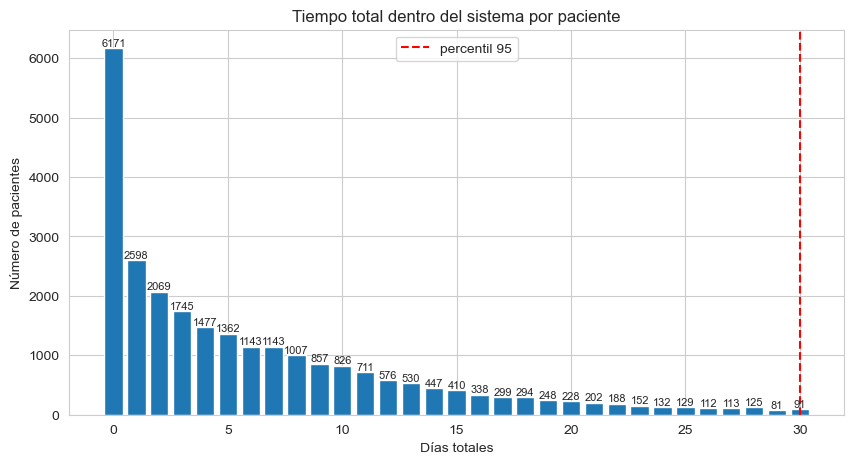

In [55]:
# Tiempo en el sistema por persona
tiempo_sis, limite_tiempo = bases.tiempo_total_paciente(df_pacientes, col_id="Id", col_dias="Duracion días", max_dias=100, quantile_outlier=0.95, graficar=True)

In [56]:
print("n pacientes:", len(tiempo_sis))
print("min:", tiempo_sis.min())
print("max:", tiempo_sis.max())
print("valores:", tiempo_sis.value_counts().head(10))

n pacientes: 27100
min: 0.0
max: 100.0
valores: Duracion días
0.0    6171
1.0    2598
2.0    2069
3.0    1745
4.0    1477
5.0    1362
6.0    1143
7.0    1143
8.0    1007
9.0     857
Name: count, dtype: int64


In [57]:
# un grafico grande y te vas quedando con info
# ir bajandolo a temas

## 3. Análisis Descriptivo por Hospital

### 3.1 Traslados por hospital

Top 10 hospitales que derivan más pacientes:


,traslados_out,traslados_in
UPA 5 AB,575.0,109.0
UPA 11 FV,374.0,83.0
MI PUEBLO,302.0,40.0
LUCIO MELENDEZ,118.0,103.0
MODULO HOSPITALARIO 9 AB,114.0,598.0
MODULO HOSPITALARIO 11 FV,101.0,618.0
UPA 17 QU,63.0,7.0
MODULO HOSPITALARIO 10 QU,39.0,72.0
ONATIVIA,31.0,6.0
EL CRUCE,22.0,104.0



Top 10 hospitales que reciben más pacientes:


,traslados_out,traslados_in
MODULO HOSPITALARIO 11 FV,101.0,618.0
MODULO HOSPITALARIO 9 AB,114.0,598.0
UPA 5 AB,575.0,109.0
EL CRUCE,22.0,104.0
LUCIO MELENDEZ,118.0,103.0
UPA 11 FV,374.0,83.0
MODULO HOSPITALARIO 10 QU,39.0,72.0
MI PUEBLO,302.0,40.0
IRIARTE,18.0,18.0
UPA 17 QU,63.0,7.0


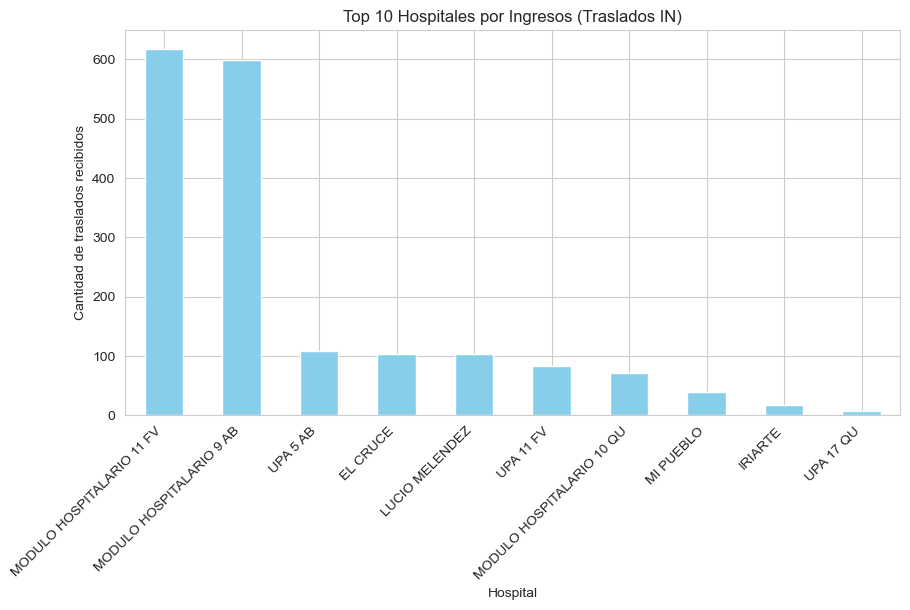

In [58]:
# Traslados OUT (Origen)
traslados_out = bases.traslados_por_hospital(traslados, col_hospital="Nombre Hospital", graficar=False)

# Traslados IN (Destino)
traslados_in = bases.traslados_por_hospital(traslados, col_hospital="Hospital siguiente", graficar=False)

tabla_hospitales = pd.DataFrame({
    "traslados_out": traslados_out,
    "traslados_in": traslados_in,
}).fillna(0)

print("Top 10 hospitales que derivan más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_out", ascending=False).head(10))

print("\nTop 10 hospitales que reciben más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_in", ascending=False).head(10))

# Graficamos los IN
tabla_hospitales["traslados_in"].sort_values(ascending=False).head(10).plot(kind="bar", color="skyblue", figsize=(10,5))
plt.title("Top 10 Hospitales por Ingresos (Traslados IN)")
plt.ylabel("Cantidad de traslados recibidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [59]:
# ESTO ES STRENGTH O FUERZA
# DEGREE: # de hospitales con los que me conecto

# fuerza/grado = numero promedio de traslados que recibo de un hospital con el que estoy conectado

### 3.2 Tiempo promedio que pasa una persona dentro del hospital

Nombre Hospital
IRIARTE                      13.772472
MODULO HOSPITALARIO 8 LZ     11.882353
MODULO HOSPITALARIO 10 QU     9.776132
ONATIVIA                      9.376883
MODULO HOSPITALARIO 11 FV     8.962939
EL CRUCE                      8.249161
MODULO HOSPITALARIO 9 AB      7.695652
MI PUEBLO                     7.645743
LUCIO MELENDEZ                7.576258
EVITA PUEBLO                  7.329577
Name: Duracion días, dtype: float64

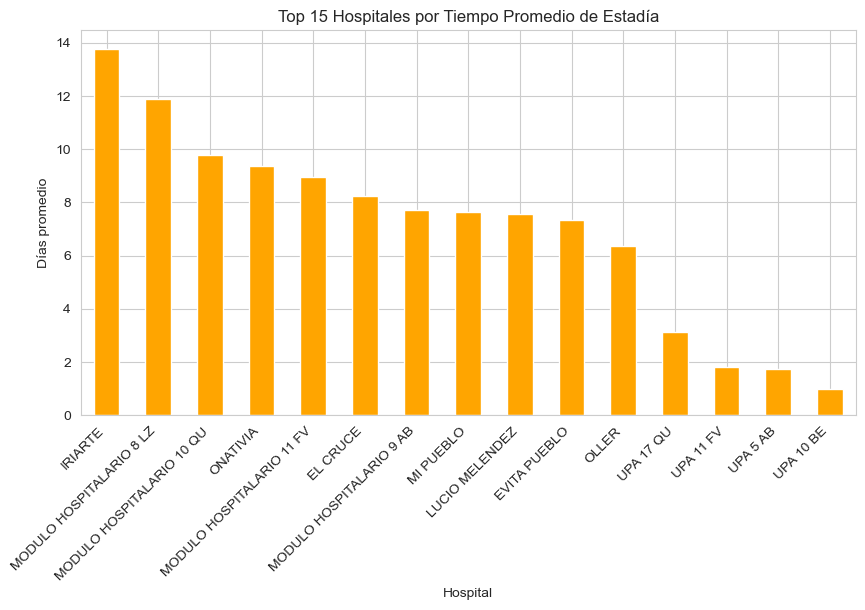

In [60]:
# Tiempo promedio por hospital
tiempo_prom_hosp = bases.tiempo_promedio_por_hospital(df_pacientes, col_hospital="Nombre Hospital", col_dias="Duracion días", quantile_outlier=0.95, graficar=False)

display(tiempo_prom_hosp.head(10))

tiempo_prom_hosp.head(15).plot(kind="bar", color="orange", figsize=(10,5))
plt.title("Top 15 Hospitales por Tiempo Promedio de Estadía")
plt.ylabel("Días promedio")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [61]:
# agregar los valores a las barras

### 3.3 Cantidad de muertos por hospital

Nombre Hospital
ONATIVIA                     595
EVITA PUEBLO                 341
IRIARTE                      323
MI PUEBLO                    311
LUCIO MELENDEZ               308
MODULO HOSPITALARIO 11 FV    278
MODULO HOSPITALARIO 10 QU    184
MODULO HOSPITALARIO 9 AB     151
EL CRUCE                     141
UPA 5 AB                      89
dtype: int64

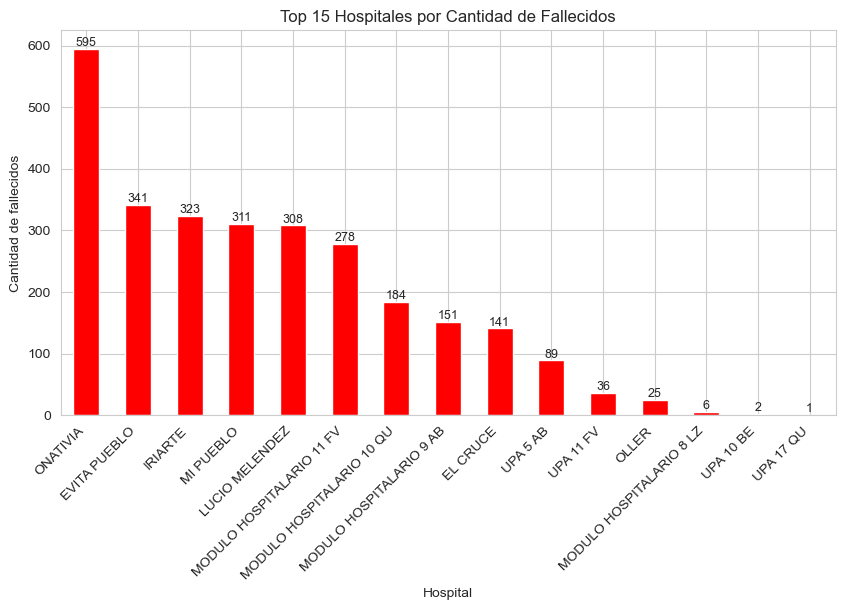

In [62]:
muertes_hosp = bases.muertes_por_hospital(
    df_pacientes,
    col_hospital="Nombre Hospital",
    col_muerte="murio",
    graficar=False
)

display(muertes_hosp.head(10))

ax = muertes_hosp.head(15).plot(kind="bar", color="red", figsize=(10,5))

# agregar numerito arriba de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Top 15 Hospitales por Cantidad de Fallecidos")
plt.ylabel("Cantidad de fallecidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [63]:
## entrar a la red o volver a casa o muerte
## version: optimista


# ver que rol tienen estos indicadores en la caminata

In [64]:
## ver los cambios de estado de las personas
## cuanta gente pasa de estado general a critico, intermedio a general, etc etc

## traslados entre hospitales  y traslados entre niveles
# la gente mejora o empeora en el hospital? cuantos?

## 4. Análisis Combinado

### 4.1 Cantidad de personas con distintos niveles de riesgo social y estados (crítico, intermedio general)

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos,Total
Nivel riesgo social,,,,
no,3404,10426,3402,17232
si,2353,1235,2373,5961
Total,5757,11661,5775,23193


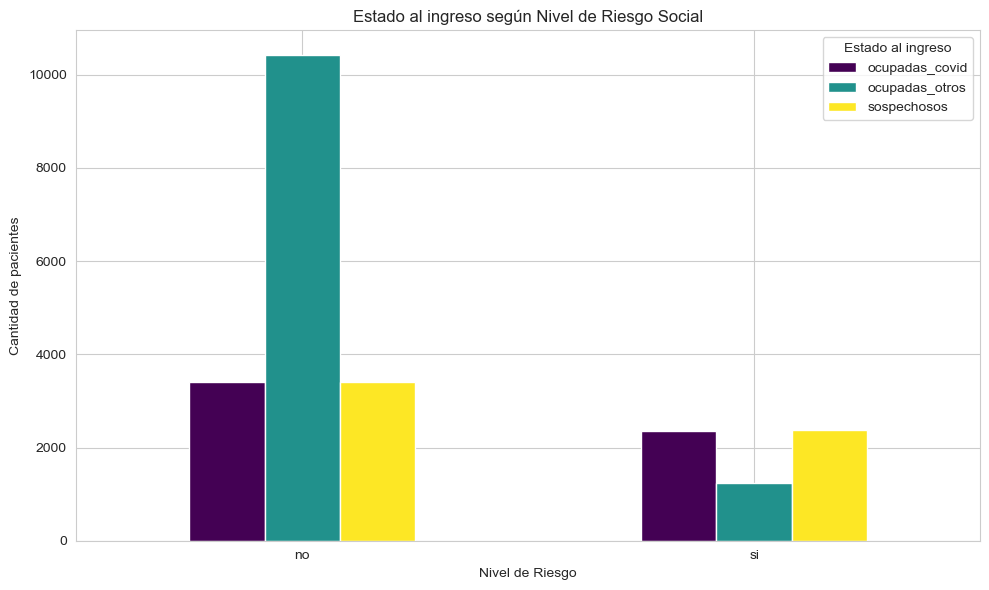

In [65]:
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
if "Nivel riesgo social" in df_pacientes.columns and "Estado al ingreso" in df_pacientes.columns:

    tabla_riesgo_estado = pd.crosstab(
        df_pacientes["Nivel riesgo social"],
        df_pacientes["Estado al ingreso"],
        margins=True,
        margins_name="Total"
    )

    display(tabla_riesgo_estado)

    tabla_sin_totales = pd.crosstab(
        df_pacientes["Nivel riesgo social"],
        df_pacientes["Estado al ingreso"]
    )

    tabla_sin_totales.plot(
        kind="bar",
        stacked=False,
        figsize=(10,6),
        colormap="viridis"
    )

    plt.title("Estado al ingreso según Nivel de Riesgo Social")
    plt.ylabel("Cantidad de pacientes")
    plt.xlabel("Nivel de Riesgo")
    plt.xticks(rotation=0)
    plt.legend(title="Estado al ingreso")
    plt.tight_layout()
    plt.show()

else:
    print("Las columnas necesarias para este análisis no están disponibles.")
    print("Columnas disponibles:", df_pacientes.columns.tolist())

### 4.2 Relacionar Secciones (Tiempos vs. Riesgo Social / Estado)

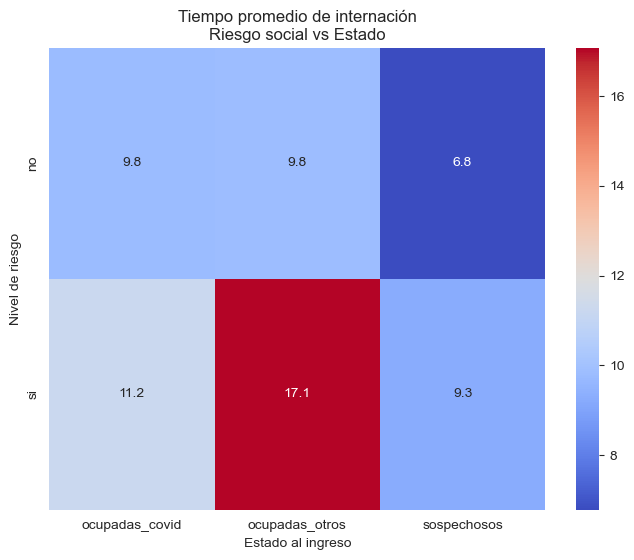

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos
Nivel riesgo social,,,
no,9.785965,9.815471,6.783468
si,11.242630,17.071625,9.259243


In [66]:
bases.relacion_tiempo_riesgo_estado(df_pacientes)